1. Loading and Cleaning Data...

Loaded 549346 rows from phishing_dataset.csv
Initial data shape: (549346, 2)
Shape after dropping missing values: (549346, 2)
Shape after dropping duplicates: (507196, 2)

Class distribution:
good    392897
bad     114299
Name: Label, dtype: int64

2. Splitting Data (Stratified)...
Training samples: 405756
Testing samples: 101440

3. Training and Tuning Random Forest Pipeline...
   Running Grid Search for Random Forest (this might take a moment)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
   Best Random Forest Parameters: {'clf__max_depth': None, 'clf__n_estimators': 100, 'tfidf__max_features': 5000}

--- Evaluating Tuned Random Forest ---
Accuracy: 0.9638
ROC-AUC:  0.9909

Classification Report:
              precision    recall  f1-score   support

    good (0)       0.96      0.99      0.98     78580
     bad (1)       0.96      0.87      0.92     22860

    accuracy                           0.96    101440
   macro avg       0.96 

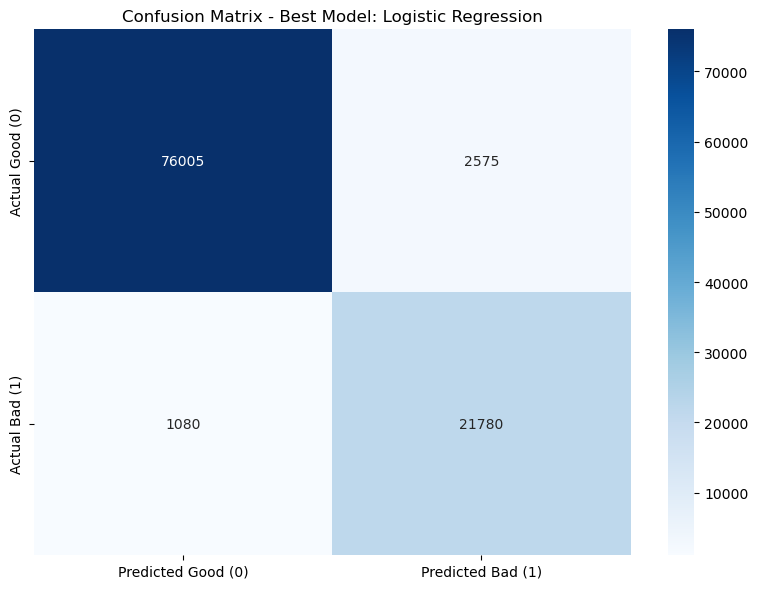

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("1. Loading and Cleaning Data...\n")

# Load the real dataset
# This will raise a FileNotFoundError if the file is not in the same folder as this script.
df = pd.read_csv('phishing_site_urls.csv')
print(f"Loaded {df.shape[0]} rows from phishing_dataset.csv")

# --- 1. Data Cleaning ---
print("Initial data shape:", df.shape)

# Drop missing values
df = df.dropna(subset=['URL', 'Label'])
print("Shape after dropping missing values:", df.shape)

# Drop duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

print("\nClass distribution:")
print(df['Label'].value_counts())

# Extract features and target
X = df['URL']
y = df['Label']

# Convert target labels to binary (0 for good, 1 for bad)
y_binary = (y == 'bad').astype(int)

# --- 2. Stratified Data Splitting ---
print("\n2. Splitting Data (Stratified)...")
# Stratified splitting ensures the proportion of good/bad URLs remains the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, 
    test_size=0.2,        # 20% of data for testing
    random_state=42,      # Seed for reproducibility
    stratify=y_binary     # Crucial: maintain class balance
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# --- Function to evaluate models ---
def evaluate_model(name, model, X_test_data, y_test_data):
    print(f"\n--- Evaluating {name} ---")
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]
    
    acc = accuracy_score(y_test_data, y_pred)
    
    try:
        auc = roc_auc_score(y_test_data, y_proba)
    except ValueError:
         auc = 0.0 # Handle edge case for tiny dummy datasets
         
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    
    print("\nClassification Report:")
    try:
        print(classification_report(y_test_data, y_pred, target_names=['good (0)', 'bad (1)']))
    except ValueError:
         print(classification_report(y_test_data, y_pred))
         
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test_data, y_pred)
    print(cm)
    
    return acc, auc, model, cm

# =====================================================================
# --- 3. First Model: Random Forest with Hyperparameter Tuning ---
# =====================================================================
print("\n3. Training and Tuning Random Forest Pipeline...")

# Create a pipeline combining feature extraction and the classifier
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',      # Analyze at the character level (good for catching weird spelling in URLs)
        ngram_range=(2, 4),   # Look at sequences of 2 to 4 characters
        lowercase=True
    )),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define the hyperparameters we want to "tune" or search through
rf_param_grid = {
    'tfidf__max_features': [1000, 5000],  # Test different vocabulary sizes
    'clf__n_estimators': [50, 100],       # Test number of trees in the forest
    'clf__max_depth': [10, None]          # Test how deep the trees can grow
}

print("   Running Grid Search for Random Forest (this might take a moment)...")
# GridSearchCV trains the model multiple times with different combinations of the parameters above
# and uses Cross-Validation (cv=3) to find the best combination.
rf_grid_search = GridSearchCV(
    rf_pipeline, 
    rf_param_grid, 
    cv=3,                 # 3-fold cross validation
    scoring='roc_auc',    # Optimize for ROC-AUC score
    n_jobs=-1,            # Use all available CPU cores
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f"   Best Random Forest Parameters: {rf_grid_search.best_params_}")
best_rf_model = rf_grid_search.best_estimator_

# Evaluate the tuned Random Forest
rf_acc, rf_auc, _, rf_cm = evaluate_model("Tuned Random Forest", best_rf_model, X_test, y_test)


# =====================================================================
# --- 4. Second Model: Logistic Regression (Classification) ---
# =====================================================================
print("\n4. Training and Tuning Logistic Regression Pipeline...")
# Note: The user asked for "linear regression", but Linear Regression is for predicting continuous numbers (like house prices).
# For classification tasks (predicting categories like good/bad), Logistic Regression is the correct linear model to use.

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 4),
        lowercase=True
    )),
    ('clf', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

# Define parameters to tune for Logistic Regression
lr_param_grid = {
    'tfidf__max_features': [1000, 5000, 10000],
    'clf__C': [0.1, 1.0, 10.0]  # Regularization strength (smaller values specify stronger regularization)
}

print("   Running Grid Search for Logistic Regression...")
lr_grid_search = GridSearchCV(
    lr_pipeline, 
    lr_param_grid, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

print(f"   Best Logistic Regression Parameters: {lr_grid_search.best_params_}")
best_lr_model = lr_grid_search.best_estimator_

# Evaluate the tuned Logistic Regression
lr_acc, lr_auc, _, lr_cm = evaluate_model("Tuned Logistic Regression", best_lr_model, X_test, y_test)


# =====================================================================
# --- 5. Compare and Save Best Model ---
# =====================================================================
print("\n5. Summary and Saving Best Model...")

models = {
    'Random Forest': (rf_acc, rf_auc, best_rf_model, rf_cm),
    'Logistic Regression': (lr_acc, lr_auc, best_lr_model, lr_cm)
}

# Determine the best model based on ROC-AUC score
best_model_name = max(models, key=lambda x: models[x][1])
best_acc, best_auc, final_model, best_cm = models[best_model_name]

print(f"\n{'=' * 50}")
print(f"🏆 BEST MODEL: {best_model_name} 🏆")
print(f"Accuracy: {best_acc:.4f} | ROC-AUC: {best_auc:.4f}")
print(f"{'=' * 50}")

# Save the final model for future use
model_filename = 'best_phishing_detector.pkl'
joblib.dump(final_model, model_filename)
print(f"\n✅ Best model saved successfully to '{model_filename}'")

# --- Bonus: Visualizing the Confusion Matrix for the best model ---
try:
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
                yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
    plt.title(f'Confusion Matrix - Best Model: {best_model_name}')
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    print("✅ Confusion matrix visualization saved as 'best_confusion_matrix.png'")
except Exception as e:
    print(f"\n❌ Could not create visualization: {e}")

# --- 6. Quick Interactive Test ---
print("\n6. Let's test the final model!")
test_urls = [
    "https://www.google.com/search?q=machine+learning",
    "http://update-paypal-security-alert-now.com/login",
    "https://my-university-portal.edu/login"
]

print("\nPredictions:")
for url in test_urls:
    prediction = final_model.predict([url])[0]
    prob = final_model.predict_proba([url])[0]
    
    result = "🔴 BAD (Phishing)" if prediction == 1 else "🟢 GOOD (Legitimate)"
    confidence = prob[prediction] * 100
    
    print(f"  URL: {url}")
    print(f"  --> {result} (Confidence: {confidence:.1f}%)\n")